<a href="https://colab.research.google.com/github/selinalee09/Python-Works/blob/main/diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df=pd.read_csv('diabetes_risk.csv')
print(df.head())

   patient_id  age  gender       city   bmi family_history_diabetes  \
0           1   47  Female     Mumbai  26.5                     Yes   
1           2   53  Female     Mumbai  20.5                     Yes   
2           3   47    Male      Thane  31.3                      No   
3           4   41    Male  Bengaluru  22.8                      No   
4           5   57  Female  Bengaluru  16.7                      No   

  physical_activity_level       diet_type smoking_status alcohol_consumption  \
0               Sedentary      Vegetarian          Never               Never   
1                Moderate      Vegetarian          Never               Never   
2                Moderate  Non-Vegetarian        Current             Regular   
3               Sedentary  Non-Vegetarian          Never               Never   
4               Sedentary  Non-Vegetarian        Current          Occasional   

   hours_sleep_per_night  stress_level  fasting_blood_sugar  hba1c_level  \
0               

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [5]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
city,0
bmi,0
family_history_diabetes,0
physical_activity_level,0
diet_type,0
smoking_status,472
alcohol_consumption,3788


In [6]:
df.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


In [7]:
df['target']=(df['diabetes_risk'] == 'High').astype(int)
df=df.drop(columns=['diabetes_risk'])

In [14]:
income_level={'Low':1, 'Middle':2, 'High':3}
df['income_bracket']=df['income_bracket'].map(income_level)

activity_level={'Low':1, 'Moderate':2, 'High':3}
df['activity_level']=df['physical_activity_level'].map(activity_level)

alcohol_level={'Low':1, 'Moderate':2, 'High':3}
df['alcohol_level']=df['alcohol_consumption'].map(alcohol_level)

In [19]:
if 'patient_id' in df.columns:
  df=df.drop(columns=['patient_id'])
df.head()

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,target,activity_level,alcohol_level
0,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,NaN,0,NaN,NaN
1,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,NaN,0,2.0,NaN
2,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,NaN,1,2.0,NaN
3,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,NaN,0,NaN,NaN
4,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,NaN,0,NaN,NaN


In [24]:
def risk_score(row):
  score=0
  if row['bmi'] >=30: score+=2
  elif row['bmi'] >=25: score+=1

  if row['fasting_blood_sugar'] >= 170: score +=2
  elif row['fasting_blood_sugar'] >= 150: score +1

  if row['hba1c_level'] >= 7: score +=2
  elif row['hba1c_level'] >= 6.5: score +=1

  if row['blood_pressure_systolic'] >= 160: score +=2
  elif row['blood_pressure_systolic'] >= 140: score +=1

  if row['blood_pressure_diastolic'] >= 90: score +=2
  elif row['blood_pressure_diastolic'] >= 80: score +=1

  if row['physical_activity_level'] == 'High': score +=2
  elif row['physical_activity_level'] == 'Moderate': score +=1

  if row['alcohol_consumption'] == 'High': score +=2
  elif row['alcohol_consumption'] == 'Moderate': score +=1

  if row['income_bracket'] == 'High': score +=2
  elif row['income_bracket'] == 'Middle': score +=1

  return score

df['risk_score']=df.apply(risk_score, axis=1)

In [25]:
def risk_tiers(score):
  if score <=3:
    return 'Low Risk'
  elif score <=7:
    return 'Moderate Risk'
  else: return 'High Risk'

df['risk_tier']=df['risk_score'].apply(risk_tiers)
df['risk_tier'].value_counts()

,count
risk_tier,
Moderate Risk,7423
Low Risk,5394
High Risk,2183


<function matplotlib.pyplot.show(close=None, block=None)>

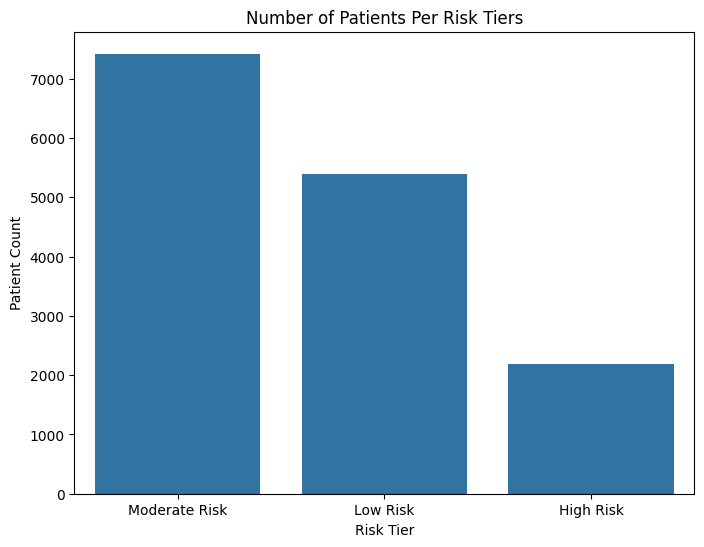

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

tier_counts=df['risk_tier'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=tier_counts.index, y=tier_counts.values)
plt.title('Number of Patients Per Risk Tiers')
plt.xlabel('Risk Tier')
plt.ylabel('Patient Count')
plt.show